# CPU+GPU Test of `calcSpatialFreqsHilbert2D`

This notebook replicates in Python/NumPy the MATLAB test script `testCalcSpatialFreqsHilbert2D.m` for the 2D Hilbert-based local spatial-frequency estimator `calcSpatialFreqsHilbert2D`. The core functions are imported from `FPA_Numpy.py` and `FPA_TensorFlow.py` .
Here we check NumPy-CPU and TensorFlow-GPU implementations

In [8]:
# ---
# ✅ Colab bootstrap for LensPMD
# How to open in Colab:
# 1) Clone the LensPMD repo into Google Drive.
# 2) In Drive (web), right-click the notebook → “Open with” → “Google Colab”.
# 3) Run this cell to mount Drive, set the working directory, and verify required paths.
# ---

import os
from pathlib import Path

# === Detect Colab =============================================================
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Colab? {IN_COLAB}")

# === Setup when in Colab ======================================================
if IN_COLAB:
    from google.colab import drive  # type: ignore
    DRIVE_MOUNT_POINT = "/content/drive"
    PROJECT_REL_PATH = "MyDrive/Colab Notebooks/72_OM4M008_LENSPMD25_CPU_GPU_FPA/Python_src"
    REQUIRED_PATH = "/content/drive/MyDrive/Colab Notebooks/72_OM4M008_LENSPMD25_CPU_GPU_FPA/local_data"

    # Mount Google Drive
    drive.mount(DRIVE_MOUNT_POINT, force_remount=True)

    # Set working directory
    project_path = Path(DRIVE_MOUNT_POINT) / PROJECT_REL_PATH
    if not project_path.exists():
        raise FileNotFoundError(f"❌ Project directory not found: {project_path}")

    os.chdir(project_path)
    print("✅ Working Directory:", Path.cwd())

    # Verify required local_data folder exists
    local_data_path = Path(REQUIRED_PATH)
    if not local_data_path.exists():
        raise FileNotFoundError(
            f"❌ Required directory not found: {local_data_path}\n"
            "Please ensure 'local_data' exists in the LensPMD folder in your Drive."
        )

    print("✅ Required folder found:", local_data_path)
    print("📂 Files in Working Directory:", os.listdir())

else:
    print("Not running in Colab — skipping Drive mount and WD setup.")
    print("Current Working Directory:", Path.cwd())


Running in Colab? False
Not running in Colab — skipping Drive mount and WD setup.
Current Working Directory: c:\user\AQ_SCC\72_OM4M008_LENSPMD25_CPU_GPU_FPA\Python_src


In [9]:
import numpy as np
import matplotlib.pyplot as plt

from FPA_Numpy import calcSpatialFreqsHilbert2D_NumPy, calcSpatialFreqsFilterbank_ParVer_NumPy
from FPA_TensorFlow import calcSpatialFreqsHilbert2D_TF, calcSpatialFreqsFilterbank_ParVer_TF
from FPA_Utils import time_method, peaks_2d



In [10]:
# Synthetic interferogram (Caso 1: HIFREQ)
NR, NC = 558, 553
y, x = np.meshgrid(
    np.arange(NR, dtype=np.float32),
    np.arange(NC, dtype=np.float32),
    indexing="ij",
)
x = x - 0.5 * NC
y = y - 0.5 * NR

# ROI mask
M = np.ones((NR, NC), dtype=bool)

# Spatial carrier
w0 = np.array([np.pi/4, np.pi/4], dtype=np.float32)  # rad/px
fringe_carrier_or = np.arctan2(w0[1], w0[0])

# Smooth phase term via peaks (already sized NR x NC)
phi_0 = 3.0 * peaks_2d(NR, NC)
phi = phi_0 + w0[0] * x + w0[1] * y

# Ground-truth spatial freqs
phi_y, phi_x = np.gradient(phi.astype(np.float32))  # np.gradient -> (d/dy, d/dx)
w_phi = np.abs(phi_x + 1j * phi_y)
w_phi = w_phi * M  # apply mask
theta_or = np.arctan2(-phi_y, phi_x)

# DC and modulation in gray values
b = np.float32(100.0)
m = np.float32(64.0)
nL_mod = np.float32(0.0)
nL = 100.0 * nL_mod / m  # not used explicitly

# Interferogram in [0, 255]
g_float = b + m * np.cos(phi) + nL_mod * np.random.randn(NR, NC).astype(np.float32)
g_uint8 = np.clip(np.round(g_float), 0, 255).astype(np.uint8)
g = g_uint8.astype(np.float32)
g = g * M.astype(np.float32)

# Ground-truth phasor (for reference)
z = b * np.exp(1j * phi)
print("Synthetic interferogram generated.")


Synthetic interferogram generated.


NumPy Hilbert (calcSpatialFreqsHilbert2D_NumPy): 10 runs -> mean = 52.03 ms, std = 1.11 ms


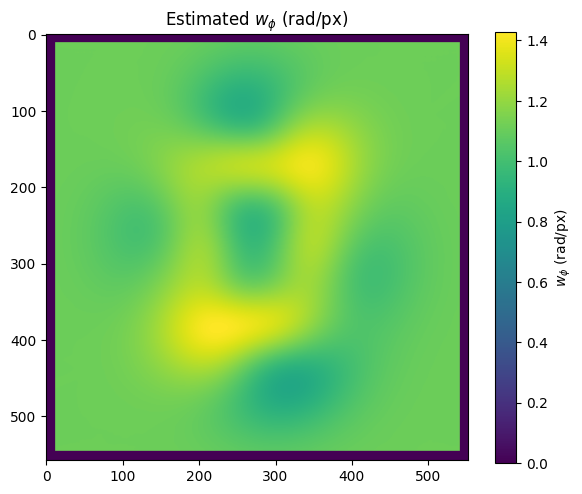

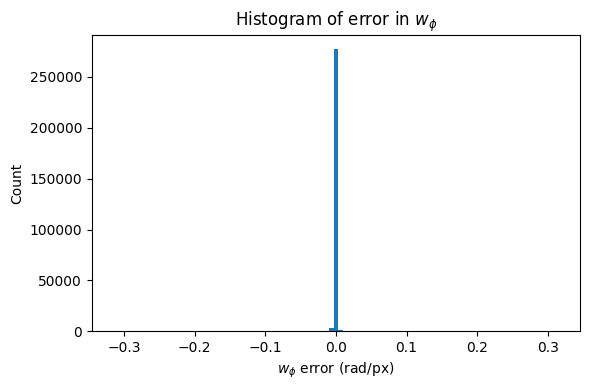

RMSE(w_phi) = 0.3214 rad/px
Assertion passed: RMSE(w_phi) < 0.4 rad/px


In [11]:
# Compute spatial frequencies with Hilbert-based method
# Time NumPy Hilbert-based method and keep outputs for plotting
(pred_w_phi, pred_theta_or, pred_phi_x, pred_phi_y, M_proc), times_numpy = time_method(
    "NumPy Hilbert (calcSpatialFreqsHilbert2D_NumPy)",
    calcSpatialFreqsHilbert2D_NumPy,
    g,
    M=M,
    filter_orientation=fringe_carrier_or,
    n_runs=10,
)

# Error map (only meaningful where M is True)
error_map_w_phi = pred_w_phi - w_phi
mask = M

# Display w_phi estimate
plt.figure(figsize=(6, 5))
plt.imshow(pred_w_phi * M_proc, origin='upper')
plt.colorbar(label=r'$w_\phi$ (rad/px)')
plt.title(r'Estimated $w_\phi$ (rad/px)')
plt.tight_layout()
plt.show()

# Histogram of error in w_phi (rad/px)
histEdge2 = np.linspace(-np.pi/10, np.pi/10, 100)
plt.figure(figsize=(6, 4))
plt.hist(error_map_w_phi[mask].ravel(), bins=histEdge2)
plt.title('Histogram of error in $w_\phi$')
plt.xlabel(r'$w_\phi$ error (rad/px)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# RMSE criterion
rmse_w_phi = np.sqrt(np.mean(error_map_w_phi[mask] ** 2))
print(f"RMSE(w_phi) = {rmse_w_phi:.4f} rad/px")
assert rmse_w_phi < 0.4, "RMSE condition failed (rmse_w_phi >= 0.4 rad/px)"
print("Assertion passed: RMSE(w_phi) < 0.4 rad/px")


TF Hilbert (calcSpatialFreqsHilbert2D_TF): 10 runs -> mean = 45.39 ms, std = 0.95 ms


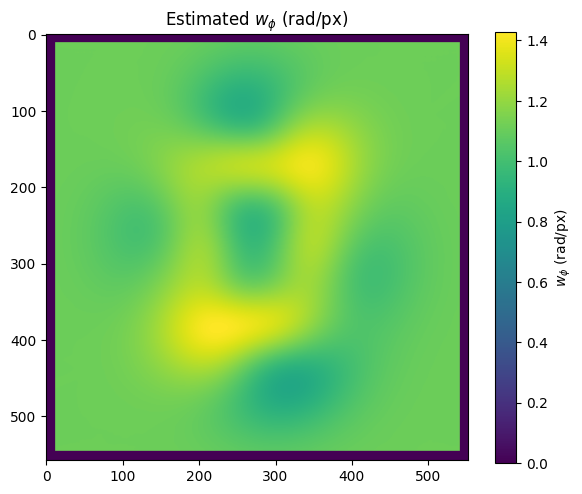

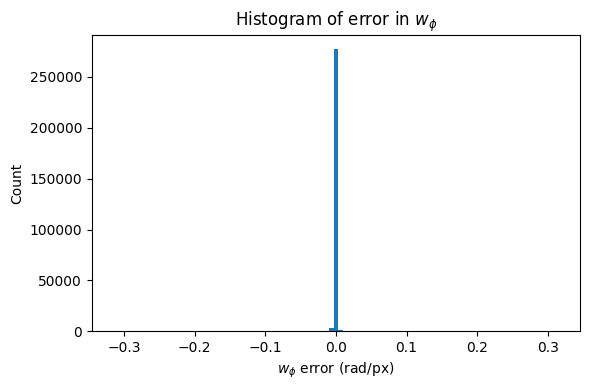

RMSE(w_phi) = 0.3214 rad/px
Assertion passed: RMSE(w_phi) < 0.4 rad/px


In [12]:
# Compute spatial frequencies with Hilbert-based method tensor flow
# Time TensorFlow Hilbert-based method (outputs kept if needed)
(pred_w_phi_tf, pred_theta_or_tf, pred_phi_x_tf, pred_phi_y_tf, M_proc_tf), times_tf_hilbert = time_method(
    "TF Hilbert (calcSpatialFreqsHilbert2D_TF)",
    calcSpatialFreqsHilbert2D_TF,
    g,
    M=M,
    filter_orientation=fringe_carrier_or,
    n_runs=10,
)

# Error map (only meaningful where M is True)
error_map_w_phi = pred_w_phi - w_phi
mask = M

# Display w_phi estimate
plt.figure(figsize=(6, 5))
plt.imshow(pred_w_phi * M_proc, origin='upper')
plt.colorbar(label=r'$w_\phi$ (rad/px)')
plt.title(r'Estimated $w_\phi$ (rad/px)')
plt.tight_layout()
plt.show()

# Histogram of error in w_phi (rad/px)
histEdge2 = np.linspace(-np.pi/10, np.pi/10, 100)
plt.figure(figsize=(6, 4))
plt.hist(error_map_w_phi[mask].ravel(), bins=histEdge2)
plt.title('Histogram of error in $w_\phi$')
plt.xlabel(r'$w_\phi$ error (rad/px)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# RMSE criterion
rmse_w_phi = np.sqrt(np.mean(error_map_w_phi[mask] ** 2))
print(f"RMSE(w_phi) = {rmse_w_phi:.4f} rad/px")
assert rmse_w_phi < 0.4, "RMSE condition failed (rmse_w_phi >= 0.4 rad/px)"
print("Assertion passed: RMSE(w_phi) < 0.4 rad/px")


Numpy Filterbank (calcSpatialFreqsFilterbank_ParVer_NumPy): 10 runs -> mean = 628.90 ms, std = 21.13 ms


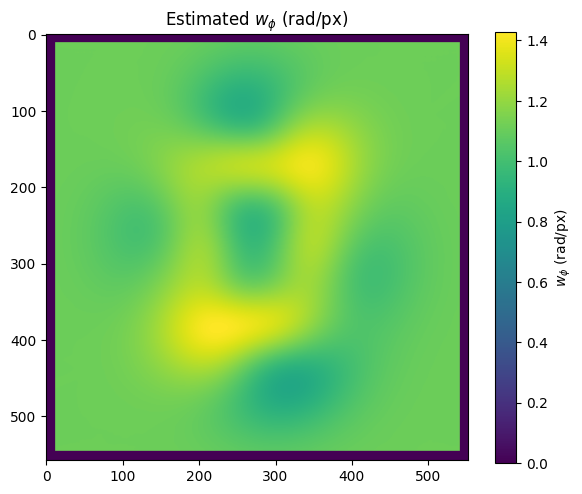

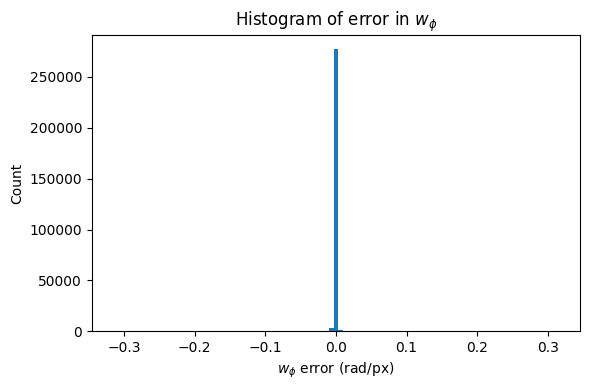

RMSE(w_phi) = 0.3214 rad/px
Assertion passed: RMSE(w_phi) < 0.4 rad/px


In [13]:
# Compute spatial frequencies with Hilbert-based method
# Time Numpy Filterbank-based method (outputs kept if needed)
(pred_w_phi_fb, pred_theta_or_fb, pred_phi_x_fb, pred_phi_y_fb, M_proc_fb), times_tf_filterbank = time_method(
    "Numpy Filterbank (calcSpatialFreqsFilterbank_ParVer_NumPy)",
    calcSpatialFreqsFilterbank_ParVer_TF,
    g,
    M=M,
    n_runs=10,
)

# Error map (only meaningful where M is True)
error_map_w_phi = pred_w_phi - w_phi
mask = M

# Display w_phi estimate
plt.figure(figsize=(6, 5))
plt.imshow(pred_w_phi * M_proc, origin='upper')
plt.colorbar(label=r'$w_\phi$ (rad/px)')
plt.title(r'Estimated $w_\phi$ (rad/px)')
plt.tight_layout()
plt.show()

# Histogram of error in w_phi (rad/px)
histEdge2 = np.linspace(-np.pi/10, np.pi/10, 100)
plt.figure(figsize=(6, 4))
plt.hist(error_map_w_phi[mask].ravel(), bins=histEdge2)
plt.title('Histogram of error in $w_\phi$')
plt.xlabel(r'$w_\phi$ error (rad/px)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# RMSE criterion
rmse_w_phi = np.sqrt(np.mean(error_map_w_phi[mask] ** 2))
print(f"RMSE(w_phi) = {rmse_w_phi:.4f} rad/px")
assert rmse_w_phi < 0.4, "RMSE condition failed (rmse_w_phi >= 0.4 rad/px)"
print("Assertion passed: RMSE(w_phi) < 0.4 rad/px")


TF Filterbank (calcSpatialFreqsFilterbank_ParVer_TF): 10 runs -> mean = 605.97 ms, std = 17.56 ms


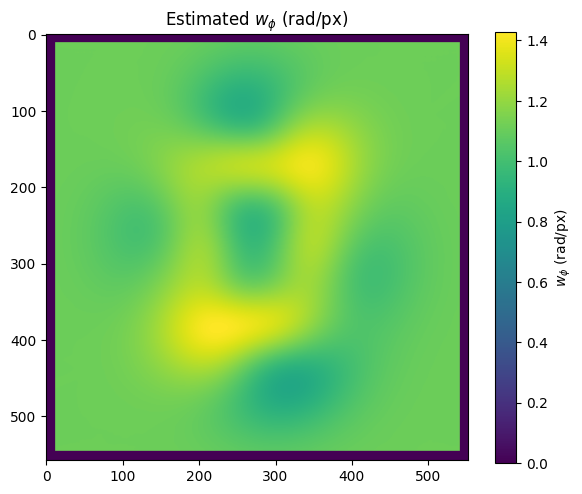

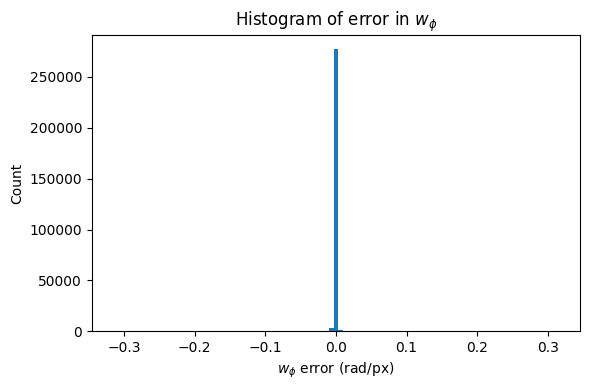

RMSE(w_phi) = 0.3214 rad/px
Assertion passed: RMSE(w_phi) < 0.4 rad/px


In [14]:
# Compute spatial frequencies with Hilbert-based method
# Time TensorFlow Filterbank-based method (outputs kept if needed)
(pred_w_phi_fb, pred_theta_or_fb, pred_phi_x_fb, pred_phi_y_fb, M_proc_fb), times_tf_filterbank = time_method(
    "TF Filterbank (calcSpatialFreqsFilterbank_ParVer_TF)",
    calcSpatialFreqsFilterbank_ParVer_TF,
    g,
    M=M,
    n_runs=10,
)
# Error map (only meaningful where M is True)
error_map_w_phi = pred_w_phi - w_phi
mask = M

# Display w_phi estimate
plt.figure(figsize=(6, 5))
plt.imshow(pred_w_phi * M_proc, origin='upper')
plt.colorbar(label=r'$w_\phi$ (rad/px)')
plt.title(r'Estimated $w_\phi$ (rad/px)')
plt.tight_layout()
plt.show()

# Histogram of error in w_phi (rad/px)
histEdge2 = np.linspace(-np.pi/10, np.pi/10, 100)
plt.figure(figsize=(6, 4))
plt.hist(error_map_w_phi[mask].ravel(), bins=histEdge2)
plt.title('Histogram of error in $w_\phi$')
plt.xlabel(r'$w_\phi$ error (rad/px)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# RMSE criterion
rmse_w_phi = np.sqrt(np.mean(error_map_w_phi[mask] ** 2))
print(f"RMSE(w_phi) = {rmse_w_phi:.4f} rad/px")
assert rmse_w_phi < 0.4, "RMSE condition failed (rmse_w_phi >= 0.4 rad/px)"
print("Assertion passed: RMSE(w_phi) < 0.4 rad/px")
